<a href="https://colab.research.google.com/github/ge25anshika-hue/Loan_Prediction_Model/blob/main/Loan_Approval_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve,classification_report
import seaborn as sns
from sklearn import svm
%matplotlib inline
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings('ignore')

In [2]:
Finance = pd.read_csv("/content/Finance_data.csv")

In [3]:
Finance

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [61]:
Finance.shape

(614, 13)

In [4]:
Finance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [5]:
Finance.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [6]:
Finance.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


**Missing values Imputation**

<Axes: xlabel='Gender', ylabel='count'>

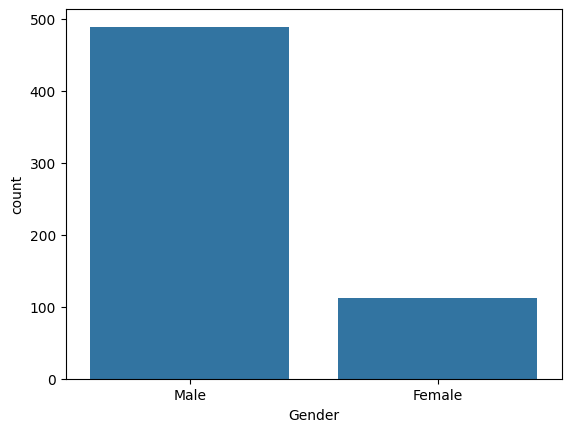

In [7]:
sns.countplot(x = Finance['Gender'])

In [8]:
Finance['Gender'].mode()[0]

'Male'

In [9]:
Finance['Gender'] = Finance['Gender'].fillna('Male')

<Axes: xlabel='Married', ylabel='count'>

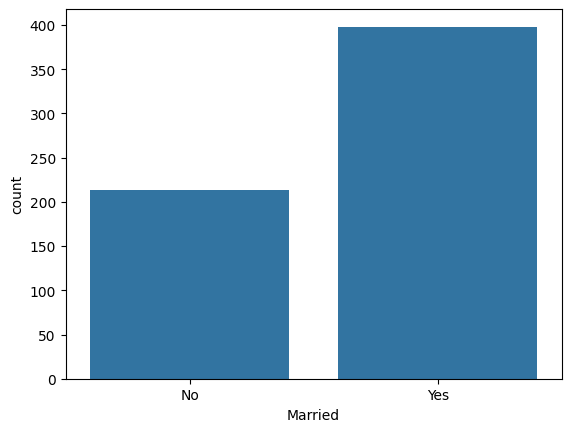

In [10]:
sns.countplot(x= Finance['Married'])

In [11]:
Finance['Married'] = Finance['Married'].fillna('Yes')

<Axes: xlabel='Dependents', ylabel='count'>

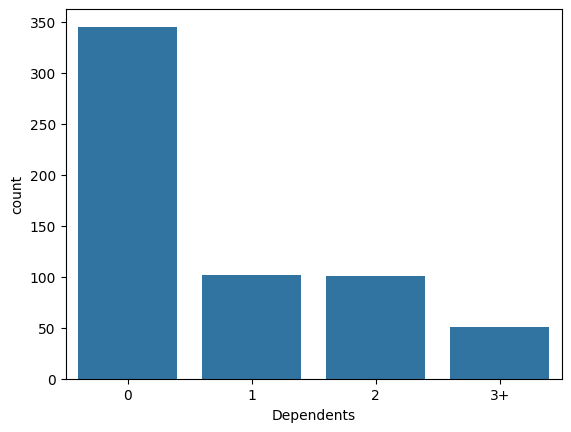

In [12]:
sns.countplot(x=Finance['Dependents'])

In [13]:
Finance['Dependents']= Finance['Dependents'].fillna('0')

<Axes: xlabel='Self_Employed', ylabel='count'>

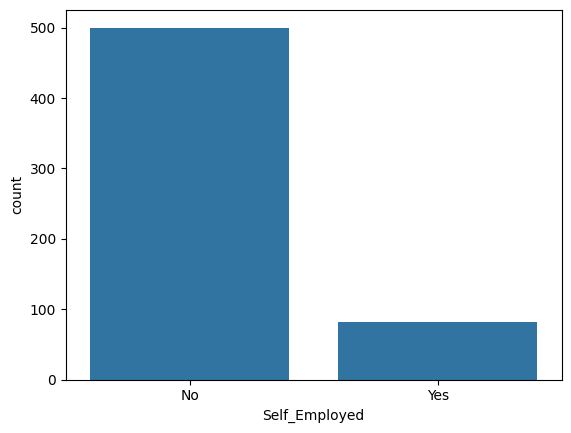

In [14]:
sns.countplot(x = Finance['Self_Employed'])

In [15]:
Finance['Self_Employed'] = Finance['Self_Employed'].fillna('No')

In [16]:
Finance['LoanAmount'] = Finance['LoanAmount'].fillna(Finance['LoanAmount'].median())

In [17]:
Finance['Loan_Amount_Term'] = Finance['Loan_Amount_Term'].fillna(Finance['Loan_Amount_Term'].median())

<Axes: xlabel='Credit_History', ylabel='count'>

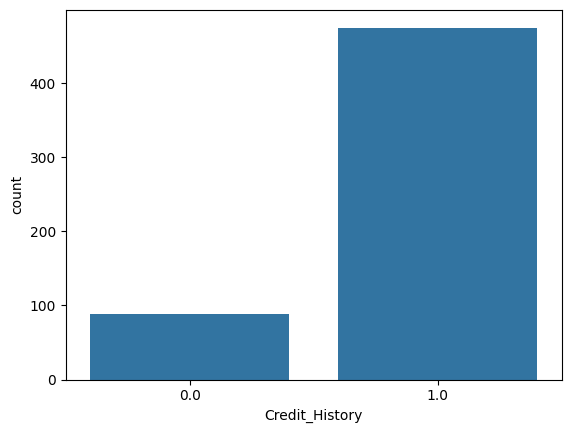

In [18]:
sns.countplot(x = Finance['Credit_History'])

In [19]:
Finance['Credit_History'] = Finance['Credit_History'].fillna('1.0')

In [20]:
Finance.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [21]:
Finance.replace({
    "Loan_Status": {'N': 0, 'Y': 1},
    "Gender": {'Male': 0, 'Female': 1},
    "Education": {'Not Graduate': 0, 'Graduate': 1},
    "Married": {'No': 0, 'Yes': 1},
    "Self_Employed": {'No': 0, 'Yes': 1}
}, inplace=True)

In [22]:
Finance.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0,0,0,1,0,5849,0.0,128.0,360.0,1.0,Urban,1
1,LP001003,0,1,1,1,0,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,0,1,0,1,1,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,0,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,0,0,0,1,0,6000,0.0,141.0,360.0,1.0,Urban,1


<Axes: xlabel='Education', ylabel='count'>

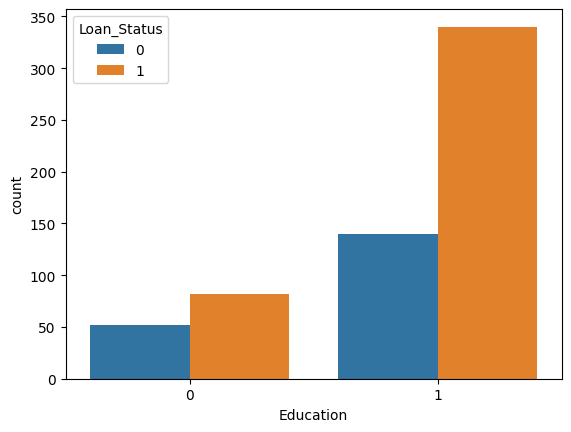

In [34]:
sns.countplot(x = 'Education', hue='Loan_Status', data=Finance)

**Train Test Split**

In [23]:
def train_test_split_and_features(Finance):
    y = Finance["Loan_Status"]
    x = Finance.drop(['Loan_Status', 'Loan_ID'], axis=1)
    x = pd.get_dummies(data = x, columns = ["Property_Area","Dependents"])
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state = 0)
    print(x.head(5))
    print(x.columns)
    features = list(x.columns)
    return x_train, x_test, y_train, y_test,features

In [24]:

x_train, x_test, y_train, y_test,features = train_test_split_and_features(Finance)

   Gender  Married  Education  Self_Employed  ApplicantIncome  \
0       0        0          1              0             5849   
1       0        1          1              0             4583   
2       0        1          1              1             3000   
3       0        1          0              0             2583   
4       0        0          1              0             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term Credit_History  \
0                0.0       128.0             360.0            1.0   
1             1508.0       128.0             360.0            1.0   
2                0.0        66.0             360.0            1.0   
3             2358.0       120.0             360.0            1.0   
4                0.0       141.0             360.0            1.0   

   Property_Area_Rural  Property_Area_Semiurban  Property_Area_Urban  \
0                False                    False                 True   
1                 True                    False   

**RANDOM FOREST CLASSIFIER**

In [25]:
def fit_and_evaluate_model(x_train, x_test, y_train, y_test):
    random_forest =  RandomForestClassifier(random_state=0,\
                                            max_depth=5,\
                                            min_samples_split= 0.01,\
                                            max_features= 0.8,
                                            max_samples= 0.8)

    model = random_forest.fit(x_train, y_train)
    random_forest_predict = random_forest.predict(x_test)
    random_forest_conf_matrix = confusion_matrix(y_test, random_forest_predict)
    random_forest_acc_score = accuracy_score(y_test, random_forest_predict)
    print("confussion matrix")
    print(random_forest_conf_matrix)
    print("\n")
    print("Accuracy of Random Forest:",random_forest_acc_score*100,'\n')
    print(classification_report(y_test,random_forest_predict))
    return model

In [26]:
model = fit_and_evaluate_model(x_train, x_test, y_train, y_test)

confussion matrix
[[14 19]
 [ 3 87]]


Accuracy of Random Forest: 82.11382113821138 

              precision    recall  f1-score   support

           0       0.82      0.42      0.56        33
           1       0.82      0.97      0.89        90

    accuracy                           0.82       123
   macro avg       0.82      0.70      0.72       123
weighted avg       0.82      0.82      0.80       123



In [27]:
importances = pd.DataFrame(model.feature_importances_)
importances['features'] = features
importances.columns = ['importance','feature']
importances.sort_values(by = 'importance', ascending= True,inplace=True)

**Feature Importance**

<BarContainer object of 16 artists>

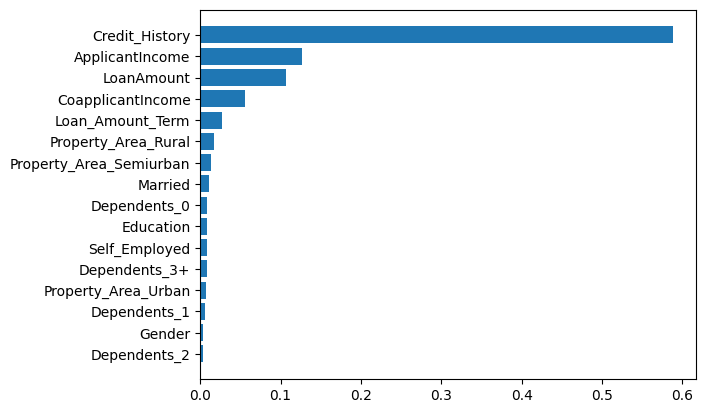

In [28]:
import matplotlib.pyplot as plt
plt.barh(importances.feature, importances.importance)

In [29]:
# Predicted Probability for each class
rf_proba = model.predict_proba(x_test)
rf_predict = model.predict(x_test)
print(rf_proba[0:10])
print(rf_predict)

[[0.19444599 0.80555401]
 [0.14819569 0.85180431]
 [0.38052013 0.61947987]
 [0.1841529  0.8158471 ]
 [0.08591748 0.91408252]
 [0.75808333 0.24191667]
 [0.2238848  0.7761152 ]
 [0.32124327 0.67875673]
 [0.88275661 0.11724339]
 [0.12933904 0.87066096]]
[1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1
 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 0 0 1 1 1 1 1 0 1]


**LOGISTIC REGRESSION**

In [30]:
from sklearn.linear_model import LogisticRegression

In [31]:
model = LogisticRegression()

In [54]:
# Features and Target
X = Finance.drop(columns='Loan_Status', axis=1)
Y = Finance['Loan_Status']

# Convert Dependents first (because of '3+')
X['Dependents'] = X['Dependents'].replace('3+', 3)

# Convert all categorical columns automatically
X = pd.get_dummies(X, drop_first=True)

# Train-Test Split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train)

# Prediction
y_pred = model.predict(x_test)

In [55]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7886178861788617


**SUPPORT VECTOR MACHINE**

In [52]:
classifier = svm.SVC(kernel='linear')


In [53]:
classifier.fit(x_train,y_train)

SVC(kernel='linear')

In [56]:
x_train_prediction = classifier.predict(x_train)
training_data_accuracy = accuracy_score(x_train_prediction, y_train)

In [57]:
print('Accuracy score of the training data : ', training_data_accuracy)

Accuracy score of the training data :  0.769857433808554


In [58]:
x_test_prediction = classifier.predict(x_test)
test_data_accuracy = accuracy_score(x_test_prediction, y_test)

In [59]:
print('Accuracy score of the test data : ', test_data_accuracy)

Accuracy score of the test data :  0.7398373983739838
